Problem 1: Use PULP to encode a linear programming problem.
---------------------------------------
This problem set will involve using a python library called PULP to formulate and solve linear programming problems.

Here is a documentation: https://www.coin-or.org/PuLP/pulp.html Examples are also attached in the tutorial that accompanies this week's reading materials.

As a "warm up" exercise, we are going to use pulp to solve a generic LP of the form

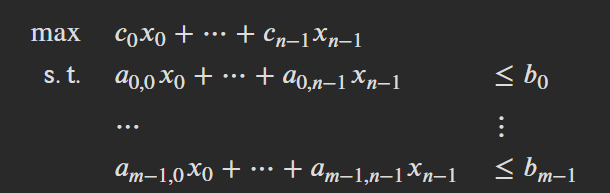

Note that to make life easier for python programmers we will index starting from  0
 . The LP has  𝑛   decision variables  𝑥0,…,𝑥𝑛−1  , and  𝑚   constraints.

The data for the problem will be given to you in the form of three lists:

list_c is a list of size n that has the objective coefficients.

list_c: [c0, ..., cn-1]

list_a is a list of  𝑚   lists where each element of list_a is itself a list of size  𝑛. This represents all the coefficients.

list_a : [ [ a00, a01, ...., a0,n-1], 
           [ a10, a11, ...., a1,n-1], 
           ...
           [ am-1,0, ...., am-1,n-1] ]

Finally, list_b is a list of size  𝑚 that has the RHS coefficients of each inequality.

list_b : [ b0,..., bm-1]

Your goal is as follows:
<ul>
<li>Given list_c, list_a, and list_b, setup the linear programming problem in Pulp, </li>
<li>Solve it and </li>
<li>Return the result. The result is defined by a tuple of three things: (is_feasible, is_bounded, opt_sol).</li>
<ul>
<li>is_feasible is a Boolean that is True if the LP is feasible and False otherwise.</li>
<li>is_bounded is a Boolean that is True if the LP is bounded and False otherwise. The value of is_bounded is meaningful only if is_feasible is True. If is_feasible is False, this value can be arbitrary.</li>
<li>opt_sol is a list of n values for decision variables  𝑥0,𝑥1,…,𝑥𝑛−1.</li>
<li>Note that opt_sol is meaningful only if is_feasible and is_bounded are both true. Failing these, the value of opt_sol can be arbitrary.</li>
</ul>
</ul>

In [1]:
try:
    %load_ext pulp
except:
    !pip install pulp

The pulp module is not an IPython extension.


In [72]:
from pulp import *

def formulate_lp_problem(m, n, list_c, list_a, list_b):
    # Assert that the data is compatible.
    assert n > 0
    assert m > 0
    assert len(list_c) == n
    assert len(list_a) == len(list_b) and len(list_b) == m
    assert all(len(l) == n for l in list_a)
    # print(f'list_c={list_c}')
    # print(f'list_a={list_a}')
    # print(f'list_b={list_b}')
    # Create a LP Model 
    # Create a linear programming model and set it to maximize its objective
    # Read this example here: https://www.coin-or.org/PuLP/CaseStudies/a_blending_problem.html
    lpModel = LpProblem('LPProblem', LpMaximize)
    ## 1. Create all the decision variables and store all the decision variables in a list
    decision_vars = [ LpVariable(f'x{i}', None, None) for i in range(n) ] 
    ## 2. Create the objective function
    objFn = None
    for i in range(n):
        objFn += list_c[i]*decision_vars[i] 
    # print(f'objFn={objFn}')
    lpModel += objFn
    ## 3. Create all the constraints
    constraints = [[float(coeff)*decision_var for (coeff, decision_var) in zip(row, decision_vars)] for row in list_a]
    # print(f'constraints={constraints}')    
    for i in range(m):
        ith_constraint = None
        for val in constraints[i]:
            ith_constraint += val
        lpModel += ith_constraint <= float(list_b[i])
    # print(f'final constraints={lpModel.constraints}')

    # your code here
    status = lpModel.solve()
    dictResults = { var.name: var.varValue  for var in lpModel.variables()}
    # print(f'dictResults={dictResults}')
    # dbg = [(var.name, var.varValue) for var in lpModel.variables()]
    # print(f'${dbg}')
    # print(f'{(status == LpStatusOptimal, status != LpStatusUnbounded, [ var.varValue for var in lpModel.variables()])}')
    return (status != LpStatusInfeasible, status != LpStatusUnbounded, [ dictResults[var.name] for var in decision_vars])

In [73]:
# Test 4
n = 15
m = 16
list_c = [1]*n 
list_c[6] = list_c[6]+1
list_a = []
list_b = []
for i in range(n):
    lst = [0]*n
    lst[i] = -1
    list_a.append(lst)
    list_b.append(0)
list_a.append([1]*n)
list_b.append(1)
(is_feas, is_bnded, sols) = formulate_lp_problem(m, n, list_c, list_a, list_b)
assert is_feas, 'Problem is feasible but your code returned infeasible'
assert is_bnded, 'Problem is bounded but your code returned unbounded'
print(sols)
assert abs(sols[6] - 1.0)  <= 1E-03, 'Solution does not match expected one'
assert all( [abs(sols[i]) <= 1E-03 for i in range(n) if i != 6]) , 'Solution does not match expected one'
print('Passed: 3 points!')

[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
Passed: 3 points!


In [74]:
m = 4
n = 3
list_c = [1, 1, 1]
list_a = [ [2, 1, 2], [1, 0, 0], [0, 1, 0], [0, 0, -1]]
list_b = [5, 7, 9, 4]
(is_feas, is_bnded, sols) = formulate_lp_problem(m, n, list_c, list_a, list_b)
assert is_feas, 'The LP should be feasible -- your code returns infeasible'
assert is_bnded, 'The LP should be bounded -- your code returns unbounded '
print(sols)
assert abs(sols[0] - 2.0) <= 1E-04 , 'x0 must be 2.0'
assert abs(sols[1] - 9.0) <= 1E-04 , 'x1 must be 9.0'
assert abs(sols[2] + 4.0) <= 1E-04 , 'x2 must be -4.0'
print('Passed: 3 points!')

[2.0, 9.0, -4.0]
Passed: 3 points!


In [75]:
# Test 2: Unbounded problem
m = 5
n = 4 
list_c = [-1, 2, 1, 1]
list_a = [ [ 1, 0, -1, 2], [2, -1, 0, 1], [1, 1, 1, 1], [1, -1, 1, 1], [0, -1, 0, 1]]
list_b = [3, 4, 5, 2.5, 3]
(is_feas, is_bnded, sols) = formulate_lp_problem(m, n, list_c, list_a, list_b)
assert is_feas, "The LP should be feasible. But your code returns a status of infeasible."
assert not is_bnded, "The LP should be unbounded but your code returns a status of bounded."
print('Passed: 3 points')

Passed: 3 points


In [76]:
# Test 3: Infeasible problem
m = 4
n = 3
list_c = [1, 1, 1]
list_a = [ [-2, -1, -2], [1, 0, 0], [0, 1, 0], [0, 0, 1]]
list_b = [-8, 1, 1, 1]
(is_feas, is_bnded, sols) = formulate_lp_problem(m, n, list_c, list_a, list_b)
assert not is_feas, 'The LP should be infeasible -- your code returns feasible'
print('Passed: 3 points!')

Passed: 3 points!


In [77]:
# Test 4
n = 15
m = 16
list_c = [1]*n 
list_c[6] = list_c[6]+1
list_a = []
list_b = []
for i in range(n):
    lst = [0]*n
    lst[i] = -1
    list_a.append(lst)
    list_b.append(0)
list_a.append([1]*n)
list_b.append(1)
(is_feas, is_bnded, sols) = formulate_lp_problem(m, n, list_c, list_a, list_b)
assert is_feas, 'Problem is feasible but your code returned infeasible'
assert is_bnded, 'Problem is bounded but your code returned unbounded'
print(sols)
assert abs(sols[6] - 1.0)  <= 1E-03, 'Solution does not match expected one'
assert all( [abs(sols[i]) <= 1E-03 for i in range(n) if i != 6]) , 'Solution does not match expected one'
print('Passed: 3 points!')

[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]
Passed: 3 points!


Problem 2: LP formulation for an investment problem
--------------------------------------------

Welcome to the world of finance! We are interested in investing in a portfolio of various stocks where we wish to maximize the overall return (profit/gain) on the investment but at the same time we do not want our investment to be diversified and the Price-to-Earnings (PE) ratio to be not too high, etc.. in order to mitigate risk. In this problem, we will develop a portfolio using linear programming.
<ul>
<li>The total budget available is given to us as an input  𝐵>0.</li>
<li>We are also given a set of possible stocks and the corresponding data. The data for each investment includes:<li>
<ul>
<li>Expected return of each investment.</li>
<li>The current price/unit of the stock.</li>
<li>The last earnings/unit of the stock.</li>
<li>The market category of the investment: Commodities, Tech, HealthCare</li>
</ul>
</ul>
Your goal is to formulate a linear programming problem for the given data in order to maximize the overall expected return subject to the following constraints:
<ul>
<li>The total cost of the investment must be less than or equal to  𝐵.</li>
<li> We are only allowed by buy non-negative ( ≥0 ) amounts of each stock (short selling is not allowed). You can buy fractions of a stock (it is interesting how that works but many online trading houses let you do that).</li>
<li>The investment must be balanced:</li>
<ul>
<li>The amount invested in each market category should be less than or equal to 2/3rds of the total budget.</li>
<li>The amount invested in each market category should be at least 1/6ths of the total budget.</li>
</ul>
<li>The price to earnings ratio of the overall portfolio should not exceed  15.</li>
</ul>

(A) Formulate on example data.
------------------------------------
Suppose we have the following six investments with IDs 1 -6 and the data (this data is purely fictional) as shown below:

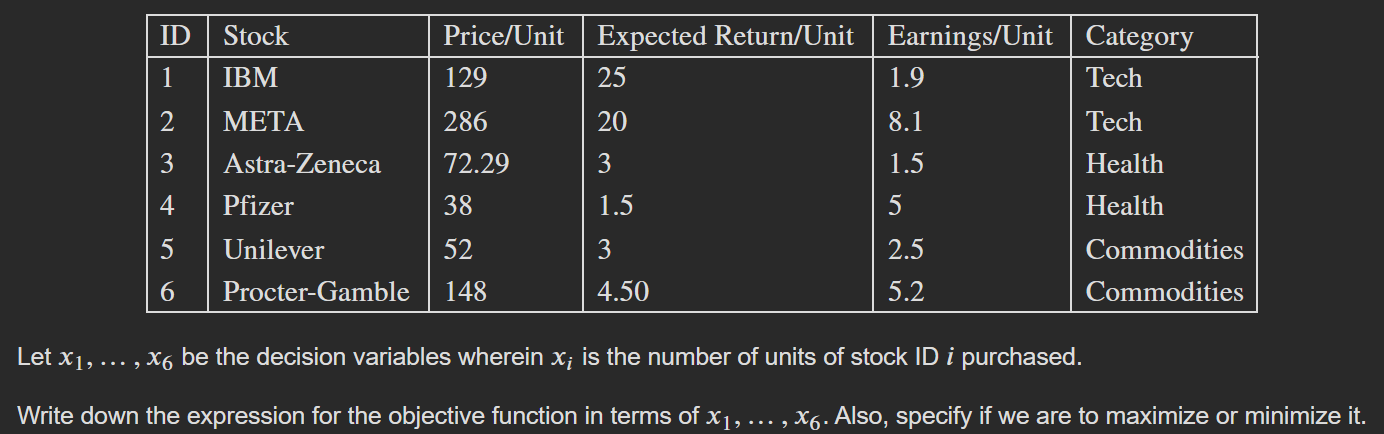


My answers for questions posed -
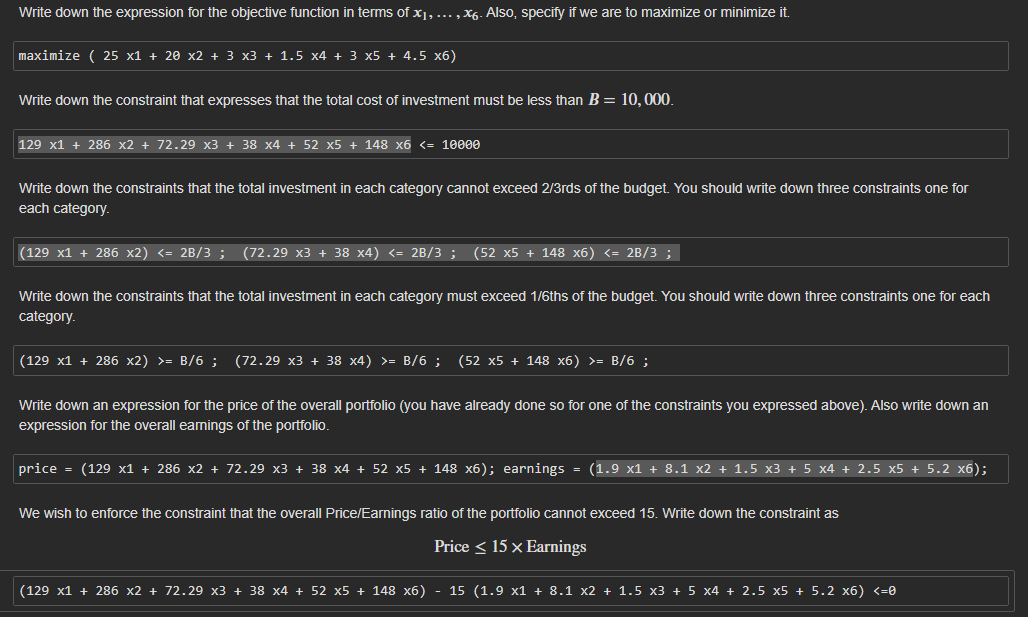

Complete the formulation of the optimization problem in Pulp. See the notes accompanying this weeks module for a tutorial on solving LPs using PULP. 
See also: https://machinelearninggeek.com/solving-linear-programming-using-python-pulp/

In [83]:
from pulp import *
# Create a linear programming model and set it to maximize its objective
# Read this example here: https://coin-or.github.io/pulp/CaseStudies/a_blending_problem.html
lpModel = LpProblem('InvestmentProblem', LpMaximize)
# Create a variable called x1 and set its bounds to be between 0 and infinity
x1 = LpVariable('x1', 0, None) 
# 1. Next create variables x2.. x6
x2 = LpVariable('x2', 0, None) 
x3 = LpVariable('x3', 0, None) 
x4 = LpVariable('x4', 0, None) 
x5 = LpVariable('x5', 0, None) 
x6 = LpVariable('x6', 0, None) 
𝐵=10000
# 2. Set the objective function: here is an example of how to do it. Use the 
#    actual objective function you worked out
lpModel +=  25*x1 + 20*x2 + 3*x3 + 1.5*x4 + 3*x5 + 4.5*x6
# 3. Add the constraints like so. Remember there is no need to set xi >= 0 since we
#    already did that when declaring the variables xi.
lpModel += 129*x1 + 286*x2 + 72.29*x3 + 38*x4 + 52*x5 + 148*x6 <= 10000
lpModel += (129*x1 + 286*x2) <= 2*(10000)/3
lpModel += (72.29*x3 + 38*x4) <= 2*(10000)/3
lpModel += (52*x5 + 148*x6) <= 2*(10000)/3
lpModel += (129*x1 + 286*x2) >= (10000)/6 
lpModel += (72.29*x3 + 38*x4) >= (10000)/6
lpModel += (52*x5 + 148*x6) >= (10000)/6
lpModel += ((129- 15*1.9)*x1 + (286-15*8.1)*x2 + (72.29-15*1.5)*x3 + (38-15*5)*x4 + (52-15*2.5)*x5 + (148-15*5.2)*x6)  <=0



# 4. We have provided the code to solve the model and print the solutions.
# your code here

# The problem is solved using PuLP's choice of Solver
lpModel.solve()
# Each of the variables is printed with it's resolved optimum value
for v in lpModel.variables():
    print(v.name, "=", v.varValue)
    
# The optimised objective function value is printed to the screen
print("Objective value = ", value(lpModel.objective))

x1 = 33.830665
x2 = 0.0
x3 = 0.0
x4 = 104.45204
x5 = 32.051282
x6 = 0.0
Objective value =  1098.598531
